# Load Library

In [1]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting

# Machine Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Evaluation Metrics
from cuml.metrics import regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Print library versions
print(f"cuDF Version: {cudf.__version__}")
print(f"CuPy Version: {cp.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# GPU Check
from numba import cuda

if cuda.is_available():
    print("\nGPU Detected:")
    device = cuda.get_current_device()
    print(f"Device Name: {device.name}") 
else:
    print("Warning: No GPU detected - Falling back to CPU mode")

2025-07-21 10:43:41.708896: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 10:43:41.755264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-21 10:43:41.795700: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-21 10:43:41.806977: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-21 10:43:41.848305: I tensorflow/core/platform/cpu_feature_guar

cuDF Version: 24.10.01
CuPy Version: 13.3.0
TensorFlow Version: 2.17.0

GPU Detected:
Device Name: b'NVIDIA GeForce RTX 4050 Laptop GPU'


# Load dataset

In [2]:
def load_datasets():
    """
    Memuat dataset Harga.csv dan Triwulan.csv dengan cudf.
    Mengembalikan tuple (harga_df, triwulan_df).
    """
    try:
        # Load Harga.csv (data harian)
        harga_df = cudf.read_csv('/home/rna_13/ModelPredict/harga.csv', parse_dates=['Tanggal'], skipinitialspace=True)
        
        # Load Triwulan.csv (data produksi)
        triwulan_df = cudf.read_csv('/home/rna_13/ModelPredict/produksi.csv', skipinitialspace=True)
        
        # Validasi keberadaan kolom penting
        required_harga_cols = {'Komoditi', 'Tanggal', ' Harga Petani ', ' Harga Pengecer '}
        required_triwulan_cols = {'Komoditi', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas', 'Produksi'}
        
        assert required_harga_cols.issubset(harga_df.columns), "Kolom tidak valid di Harga.csv"
        assert required_triwulan_cols.issubset(triwulan_df.columns), "Kolom tidak valid di Triwulan.csv"
        
        print("✔ Dataset berhasil dimuat")
        print(f"- Harga.csv: {len(harga_df)} baris")
        print(f"- Triwulan.csv: {len(triwulan_df)} baris")
        
        return harga_df, triwulan_df
    
    except FileNotFoundError as e:
        print(f"❌ File tidak ditemukan: {e}")
        return None, None
    except Exception as e:
        print(f"❌ Error saat memuat dataset: {e}")
        return None, None

# Contoh penggunaan
harga_df, triwulan_df = load_datasets()

if harga_df is not None:
    print("\n5 baris pertama harga.csv:")
    print(harga_df.head())

if triwulan_df is not None:
    print("\n5 baris pertama Produksi.csv:")
    print(triwulan_df.head())

✔ Dataset berhasil dimuat
- Harga.csv: 4382 baris
- Triwulan.csv: 30 baris

5 baris pertama harga.csv:
              Komoditi    Tanggal   Harga Petani    Harga Pengecer 
0  Jagung Pipil Kering 2022-01-03            4800              5000
1  Jagung Pipil Kering 2022-01-04            4800              5000
2  Jagung Pipil Kering 2022-01-05            4800              5000
3  Jagung Pipil Kering 2022-01-06            4800              5000
4  Jagung Pipil Kering 2022-01-07            4800              5000

5 baris pertama Produksi.csv:
     Komoditi  tahun  triwulan  Luas Panen  Produktivitas   Produksi
0  Padi sawah   2022         1  35685.6200      56.593625  201957.86
1  Padi sawah   2022         2  12599.0000      54.279752   68387.06
2  Padi sawah   2022         3   6888.7897      55.240632   38054.11
3  Padi sawah   2023         1  26790.3606      55.977470  149965.66
4  Padi sawah   2023         2  21687.8044      58.797478  127518.82


# Pembersihan data

In [3]:
harga_df = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

In [4]:
harga_df['Komoditi'].unique()

0    Jagung Pipil Kering
1           Beras Medium
2          Beras Premium
3           Kacang Hijau
Name: Komoditi, dtype: object

In [5]:
df_harga = harga_df[harga_df['Komoditi'] == 'Jagung Pipil Kering']

In [6]:
df_harga['Tipe'] = 'Undefined'

In [7]:
df_harga['Periode'] = '0'

In [8]:
df_harga=df_harga.sort_values(by='Tanggal')
df_harga=df_harga.reset_index()
df_harga=df_harga.drop(columns=['index'])


In [9]:
df_harga

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Jagung Pipil Kering,2022-01-03,4800,5000,Undefined,0
1,Jagung Pipil Kering,2022-01-04,4800,5000,Undefined,0
2,Jagung Pipil Kering,2022-01-05,4800,5000,Undefined,0
3,Jagung Pipil Kering,2022-01-06,4800,5000,Undefined,0
4,Jagung Pipil Kering,2022-01-07,4800,5000,Undefined,0
...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Undefined,0
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Undefined,0
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Undefined,0
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Undefined,0


# Feature Enginering

In [10]:
q1_2022_start = pd.to_datetime('2022-01-01')
q1_2022_end = pd.to_datetime('2022-04-30')

q2_2022_start = pd.to_datetime('2022-05-01')
q2_2022_end = pd.to_datetime('2022-08-31')

q3_2022_start = pd.to_datetime('2022-09-01')
q3_2022_end = pd.to_datetime('2022-12-31')

q1_2023_start = pd.to_datetime('2023-01-01')
q1_2023_end = pd.to_datetime('2023-04-30')

q2_2023_start = pd.to_datetime('2023-05-01')
q2_2023_end = pd.to_datetime('2023-08-31')

q3_2023_start = pd.to_datetime('2023-09-01')
q3_2023_end = pd.to_datetime('2023-12-31')

q1_2024_start = pd.to_datetime('2024-01-01')
q1_2024_end = pd.to_datetime('2024-04-30')

q2_2024_start = pd.to_datetime('2024-05-01')
q2_2024_end = pd.to_datetime('2024-08-31')

q3_2024_start = pd.to_datetime('2024-09-01')
q3_2024_end = pd.to_datetime('2024-12-31')

In [11]:
df_harga.loc[(df_harga['Tanggal'] >= q1_2022_start) & (df_harga['Tanggal'] <= q1_2022_end), 'Periode'] = 'Q1-2022'
df_harga.loc[(df_harga['Tanggal'] >= q2_2022_start) & (df_harga['Tanggal'] <= q2_2022_end), 'Periode'] = 'Q2-2022'
df_harga.loc[(df_harga['Tanggal'] >= q3_2022_start) & (df_harga['Tanggal'] <= q3_2022_end), 'Periode'] = 'Q3-2022'
df_harga.loc[(df_harga['Tanggal'] >= q1_2023_start) & (df_harga['Tanggal'] <= q1_2023_end), 'Periode'] = 'Q1-2023'
df_harga.loc[(df_harga['Tanggal'] >= q2_2023_start) & (df_harga['Tanggal'] <= q2_2023_end), 'Periode'] = 'Q2-2023'
df_harga.loc[(df_harga['Tanggal'] >= q3_2023_start) & (df_harga['Tanggal'] <= q3_2023_end), 'Periode'] = 'Q3-2023'
df_harga.loc[(df_harga['Tanggal'] >= q1_2024_start) & (df_harga['Tanggal'] <= q1_2024_end), 'Periode'] = 'Q1-2024'
df_harga.loc[(df_harga['Tanggal'] >= q2_2024_start) & (df_harga['Tanggal'] <= q2_2024_end), 'Periode'] = 'Q2-2024'
df_harga.loc[(df_harga['Tanggal'] >= q3_2024_start) & (df_harga['Tanggal'] <= q3_2024_end), 'Periode'] = 'Q3-2024'

In [12]:
triwulan_df['Tipe'] = 'Undefined'

In [13]:
triwulan_df.loc[(triwulan_df['Komoditi'] == 'Padi sawah'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi gogo'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi total'), 'Tipe'] = 'Padi'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'jagung'), 'Tipe'] = 'Jagung'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'kacang hijau'), 'Tipe'] = 'Kacang Hijau'

In [14]:
df_harga.loc[(df_harga['Komoditi'] == 'Jagung Pipil Kering'), 'Tipe'] = 'Jagung'

In [15]:
df_harga

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Jagung Pipil Kering,2022-01-03,4800,5000,Jagung,Q1-2022
1,Jagung Pipil Kering,2022-01-04,4800,5000,Jagung,Q1-2022
2,Jagung Pipil Kering,2022-01-05,4800,5000,Jagung,Q1-2022
3,Jagung Pipil Kering,2022-01-06,4800,5000,Jagung,Q1-2022
4,Jagung Pipil Kering,2022-01-07,4800,5000,Jagung,Q1-2022
...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Jagung,Q3-2024
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Jagung,Q3-2024
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Jagung,Q3-2024
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Jagung,Q3-2024


In [16]:
triwulan_df['Periode'] = "Q" + triwulan_df['triwulan'].astype(str) + "-" + triwulan_df['tahun'].astype(str)

In [17]:
df_merged = cudf.merge(
    df_harga,
    triwulan_df,
    left_on=['Periode', 'Tipe'], # Kolom dari df_penjualan
    right_on=['Periode', 'Tipe'],       # Kolom dari df_kehadiran
    how='left'                               # Pilih jenis join sesuai kebutuhanmu
)

In [18]:
df_merged=df_merged.sort_values(by='Tanggal')
df_merged=df_merged.reset_index()
df_merged=df_merged.drop(columns=['index', 'triwulan'])
df_merged

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,Komoditi_y,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2022-01-03,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
1,Jagung Pipil Kering,2022-01-04,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
2,Jagung Pipil Kering,2022-01-05,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
3,Jagung Pipil Kering,2022-01-06,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
4,Jagung Pipil Kering,2022-01-07,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
...,...,...,...,...,...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>


In [19]:
df_merged=df_merged.drop(columns=['Komoditi_y'])
df_merged = df_merged.rename(columns={'Komoditi_x' : 'Komoditi'})

In [20]:
df_merged=df_merged.to_pandas()

In [21]:
df_merged

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2022-01-03,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
1,Jagung Pipil Kering,2022-01-04,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
2,Jagung Pipil Kering,2022-01-05,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
3,Jagung Pipil Kering,2022-01-06,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
4,Jagung Pipil Kering,2022-01-07,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
...,...,...,...,...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
1090,Jagung Pipil Kering,2024-12-28,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
1091,Jagung Pipil Kering,2024-12-29,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
1092,Jagung Pipil Kering,2024-12-30,NaN,NaN,Jagung,Q3-2024,NaN,NaN,NaN,NaN


In [22]:
df_train=df_merged[(df_merged['Tanggal'] >= '2022-01-01') & (df_merged['Tanggal'] <= '2023-12-31')].copy()

# Handling Missing Values

In [23]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import pandas as pd

def stl_imputation(series, period=30):
    """
    Mengisi missing value (NaN) dalam deret waktu menggunakan dekomposisi STL.
    
    Argumen:
    series (pd.Series): Deret waktu dengan kemungkinan missing value (NaN).
    period (int): Periode musiman deret waktu (misal 30 untuk data harian bulanan).

    Mengembalikan:
    pd.Series: Deret waktu dengan missing value yang sudah diisi.
    """
    
    # Pastikan series adalah Pandas Series dan indeksnya berupa datetime
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    
    # Buat salinan seri untuk bekerja, agar tidak mengubah seri asli
    imputed_series = series.copy()
    
    # Identifikasi indeks missing values
    missing_indices = imputed_series[imputed_series.isnull()].index
    
    if missing_indices.empty:
        print("Tidak ada missing value untuk diisi.")
        return series
        
    print(f"Mengisi {len(missing_indices)} missing value menggunakan STL imputation...")

    # Langkah 1: Interpolasi awal untuk mengisi NaN sementara.
    # STL tidak bisa bekerja dengan NaN di tengah seri.
    # Interpolasi linear adalah pilihan umum untuk ini.
    temp_series = imputed_series.interpolate(method='linear', limit_direction='both')
    
    # Jika masih ada NaN di awal/akhir setelah interpolasi, isi dengan mean
    if temp_series.isnull().any():
        temp_series = temp_series.fillna(temp_series.mean())

    # Langkah 2: Dekomposisi STL
    # Pastikan period sesuai dengan data Anda (misal 30 untuk bulanan)
    stl = STL(temp_series, period=period, robust=True)
    result = stl.fit()
    
    # Langkah 3: Rekonstruksi tanpa noise (menggunakan trend + seasonal)
    reconstructed_values = result.trend + result.seasonal
    
    # Langkah 4: Isi missing value dengan nilai rekonstruksi
    # Kita hanya mengganti nilai di indeks yang tadinya NaN
    imputed_series.loc[missing_indices] = reconstructed_values.loc[missing_indices]
    
    print("Pengisian missing value selesai.")
    return imputed_series


print("DataFrame sebelum imputasi:")
print(df_train)
print("\nMissing values sebelum imputasi:")
print(df_train['Harga Petani'].isnull().sum())
print(df_train['Harga Pengecer'].isnull().sum())


# Pastikan kolom 'Tanggal' adalah indeks

# Untuk satu komoditi :
df_train['Harga Petani'] = stl_imputation(df_train['Harga Petani'], period=30) # Asumsi periode mingguan
df_train['Harga Pengecer'] = stl_imputation(df_train['Harga Pengecer'], period=30)


print("\nDataFrame setelah imputasi:")
print(df_train)
print("\nMissing values setelah imputasi:")
print(df_train['Harga Petani'].isnull().sum())
print(df_train['Harga Pengecer'].isnull().sum())

DataFrame sebelum imputasi:
                Komoditi    Tanggal  Harga Petani  Harga Pengecer    Tipe  \
0    Jagung Pipil Kering 2022-01-03        4800.0          5000.0  Jagung   
1    Jagung Pipil Kering 2022-01-04        4800.0          5000.0  Jagung   
2    Jagung Pipil Kering 2022-01-05        4800.0          5000.0  Jagung   
3    Jagung Pipil Kering 2022-01-06        4800.0          5000.0  Jagung   
4    Jagung Pipil Kering 2022-01-07        4800.0          5000.0  Jagung   
..                   ...        ...           ...             ...     ...   
723  Jagung Pipil Kering 2023-12-27        5700.0          6000.0  Jagung   
724  Jagung Pipil Kering 2023-12-28        5700.0          6000.0  Jagung   
725  Jagung Pipil Kering 2023-12-29        5700.0          6000.0  Jagung   
726  Jagung Pipil Kering 2023-12-30        5700.0          6000.0  Jagung   
727  Jagung Pipil Kering 2023-12-31           NaN             NaN  Jagung   

     Periode   tahun   Luas Panen  Produktivita

In [24]:
df_train

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907


In [25]:
# 1. Hari dalam sebulan (Day)
df_train['Hari'] = df_train['Tanggal'].dt.day

# 2. Bulan (Month)
df_train['Bulan'] = df_train['Tanggal'].dt.month

# 3. Tahun (Year)
df_train['Tahun'] = df_train['Tanggal'].dt.year

In [26]:
df_train=df_train.reset_index()
df_train=df_train.drop(columns=['index'])

In [27]:
df=df_train.copy()
df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,1,2022
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,1,2022
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,1,2022
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,1,2022
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,12,2023
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,12,2023
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,12,2023
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,30,12,2023


In [28]:
df.isnull().sum()

Komoditi          0
Tanggal           0
Harga Petani      0
Harga Pengecer    0
Tipe              0
Periode           0
tahun             0
Luas Panen        0
Produktivitas     0
Produksi          0
Hari              0
Bulan             0
Tahun             0
dtype: int64

In [29]:
data_train=df[(df['Tanggal'] >= '2022-01-01') & (df['Tanggal'] <= '2023-12-31')].copy()

In [30]:
data_train

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,1,2022
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,1,2022
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,1,2022
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,1,2022
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,12,2023
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,12,2023
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,12,2023
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,30,12,2023


## membagi data train dan test

In [31]:
# Hitung indeks pembagian (80% train, 20% test)
split_idx = int(len(data_train) * 0.8)

# Bagi data
train_df = data_train.iloc[:split_idx]
test_df = data_train.iloc[split_idx:]
test_df=test_df.reset_index()
test_df=test_df.drop(columns=['index'])

# Normalisasi Data

In [32]:
scaler = MinMaxScaler()

In [33]:
kolom_scale = ['Harga Petani', 'Harga Pengecer', 'Luas Panen', 'Produktivitas', 'Produksi']
data_scaling_train = train_df[kolom_scale]
data_scaling_test = test_df[kolom_scale]

In [34]:
data_scaling_train

,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi
0,4800.000000,5000.000000,70654.48313,73.898901,522128.8683
1,4800.000000,5000.000000,70654.48313,73.898901,522128.8683
2,4800.000000,5000.000000,70654.48313,73.898901,522128.8683
3,4800.000000,5000.000000,70654.48313,73.898901,522128.8683
4,4800.000000,5000.000000,70654.48313,73.898901,522128.8683
...,...,...,...,...,...
577,4700.000000,4800.000000,17906.79520,71.067653,127259.3909
578,4700.000000,4800.000000,17906.79520,71.067653,127259.3909
579,4730.144498,4862.411830,17906.79520,71.067653,127259.3909
580,4733.331465,4869.634884,17906.79520,71.067653,127259.3909


In [35]:
data_scaling_test

,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi
0,4700.000000,4800.000000,17906.7952,71.067653,127259.39090
1,4700.000000,4800.000000,17906.7952,71.067653,127259.39090
2,4700.000000,4800.000000,17906.7952,71.067653,127259.39090
3,4700.000000,4800.000000,17906.7952,71.067653,127259.39090
4,4769.118917,4914.741927,17906.7952,71.067653,127259.39090
...,...,...,...,...,...
141,5700.000000,6000.000000,9353.0426,81.165084,75914.04907
142,5700.000000,6000.000000,9353.0426,81.165084,75914.04907
143,5700.000000,6000.000000,9353.0426,81.165084,75914.04907
144,5700.000000,6000.000000,9353.0426,81.165084,75914.04907


In [36]:
scaled_data_train = scaler.fit_transform(data_scaling_train.to_numpy())
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']
scaled_train = pd.DataFrame(scaled_data_train, columns=nama_kolom_scaled_baru)
scaled_train

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.833333,0.876264,1.000000,1.00000,1.000000
1,0.833333,0.876264,1.000000,1.00000,1.000000
2,0.833333,0.876264,1.000000,1.00000,1.000000
3,0.833333,0.876264,1.000000,1.00000,1.000000
4,0.833333,0.876264,1.000000,1.00000,1.000000
...,...,...,...,...,...
577,0.777778,0.752529,0.102342,0.45646,0.103457
578,0.777778,0.752529,0.102342,0.45646,0.103457
579,0.794525,0.791141,0.102342,0.45646,0.103457
580,0.796295,0.795610,0.102342,0.45646,0.103457


In [37]:
scaled_data_test = scaler.transform(data_scaling_test.to_numpy())
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']
scaled_test = pd.DataFrame(scaled_data_test, columns=nama_kolom_scaled_baru)
scaled_test

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.777778,0.752529,0.102342,0.456460,0.103457
1,0.777778,0.752529,0.102342,0.456460,0.103457
2,0.777778,0.752529,0.102342,0.456460,0.103457
3,0.777778,0.752529,0.102342,0.456460,0.103457
4,0.816177,0.823517,0.102342,0.456460,0.103457
...,...,...,...,...,...
141,1.333333,1.494943,-0.043225,2.394955,-0.013121
142,1.333333,1.494943,-0.043225,2.394955,-0.013121
143,1.333333,1.494943,-0.043225,2.394955,-0.013121
144,1.333333,1.494943,-0.043225,2.394955,-0.013121


In [38]:
train_df[nama_kolom_scaled_baru] = scaled_train
train_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,3,1,2022,0.833333,0.876264,1.000000,1.00000,1.000000
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,4,1,2022,0.833333,0.876264,1.000000,1.00000,1.000000
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,5,1,2022,0.833333,0.876264,1.000000,1.00000,1.000000
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,6,1,2022,0.833333,0.876264,1.000000,1.00000,1.000000
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,7,1,2022,0.833333,0.876264,1.000000,1.00000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,Jagung Pipil Kering,2023-08-03,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,3,8,2023,0.777778,0.752529,0.102342,0.45646,0.103457
578,Jagung Pipil Kering,2023-08-04,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,4,8,2023,0.777778,0.752529,0.102342,0.45646,0.103457
579,Jagung Pipil Kering,2023-08-05,4730.144498,4862.411830,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,5,8,2023,0.794525,0.791141,0.102342,0.45646,0.103457
580,Jagung Pipil Kering,2023-08-06,4733.331465,4869.634884,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,6,8,2023,0.796295,0.795610,0.102342,0.45646,0.103457


In [39]:
test_df[nama_kolom_scaled_baru] = scaled_test
test_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,Jagung Pipil Kering,2023-08-08,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,8,8,2023,0.777778,0.752529,0.102342,0.456460,0.103457
1,Jagung Pipil Kering,2023-08-09,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,9,8,2023,0.777778,0.752529,0.102342,0.456460,0.103457
2,Jagung Pipil Kering,2023-08-10,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,10,8,2023,0.777778,0.752529,0.102342,0.456460,0.103457
3,Jagung Pipil Kering,2023-08-11,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,11,8,2023,0.777778,0.752529,0.102342,0.456460,0.103457
4,Jagung Pipil Kering,2023-08-12,4769.118917,4914.741927,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,12,8,2023,0.816177,0.823517,0.102342,0.456460,0.103457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,27,12,2023,1.333333,1.494943,-0.043225,2.394955,-0.013121
142,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,28,12,2023,1.333333,1.494943,-0.043225,2.394955,-0.013121
143,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,29,12,2023,1.333333,1.494943,-0.043225,2.394955,-0.013121
144,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,30,12,2023,1.333333,1.494943,-0.043225,2.394955,-0.013121


In [40]:
train_df['hari_sin'] = np.sin(2 * np.pi * train_df['Hari']/30)
train_df['hari_cos'] = np.cos(2 * np.pi * train_df['Hari']/30)
train_df['bulan_sin'] = np.sin(2 * np.pi * train_df['Bulan']/12)
train_df['bulan_cos'] = np.cos(2 * np.pi * train_df['Bulan']/12)

In [41]:
test_df['hari_sin'] = np.sin(2 * np.pi * test_df['Hari']/30)
test_df['hari_cos'] = np.cos(2 * np.pi * test_df['Hari']/30)
test_df['bulan_sin'] = np.sin(2 * np.pi * test_df['Bulan']/12)
test_df['bulan_cos'] = np.cos(2 * np.pi * test_df['Bulan']/12)

In [42]:
# c. Normalisasi tahun train
tahun_min = train_df['Tahun'].min()
tahun_max = train_df['Tahun'].max()
train_df['tahun_norm'] = (train_df['Tahun'] - tahun_min) / (tahun_max - tahun_min)

In [43]:
# c. Normalisasi tahun test
tahun_min = test_df['Tahun'].min()
tahun_max = test_df['Tahun'].max()
test_df['tahun_norm'] = (test_df['Tahun'] - tahun_min) / (tahun_max - tahun_min)

In [44]:
test_df['tahun_norm'] = np.nan_to_num(test_df['tahun_norm'], nan=0.0)

In [45]:
temp_column_train=[
    'hari_sin',
    'hari_cos',
    'bulan_sin',
    'bulan_cos',
    'tahun_norm'
]

In [46]:
train_df[temp_column_train]

,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,0.587785,0.809017,0.500000,0.866025,0.0
1,0.743145,0.669131,0.500000,0.866025,0.0
2,0.866025,0.500000,0.500000,0.866025,0.0
3,0.951057,0.309017,0.500000,0.866025,0.0
4,0.994522,0.104528,0.500000,0.866025,0.0
...,...,...,...,...,...
577,0.587785,0.809017,-0.866025,-0.500000,1.0
578,0.743145,0.669131,-0.866025,-0.500000,1.0
579,0.866025,0.500000,-0.866025,-0.500000,1.0
580,0.951057,0.309017,-0.866025,-0.500000,1.0


In [47]:
test_df[temp_column_train]

,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,9.945219e-01,-0.104528,-8.660254e-01,-0.5,0.0
1,9.510565e-01,-0.309017,-8.660254e-01,-0.5,0.0
2,8.660254e-01,-0.500000,-8.660254e-01,-0.5,0.0
3,7.431448e-01,-0.669131,-8.660254e-01,-0.5,0.0
4,5.877853e-01,-0.809017,-8.660254e-01,-0.5,0.0
...,...,...,...,...,...
141,-5.877853e-01,0.809017,-2.449294e-16,1.0,0.0
142,-4.067366e-01,0.913545,-2.449294e-16,1.0,0.0
143,-2.079117e-01,0.978148,-2.449294e-16,1.0,0.0
144,-1.133108e-15,1.000000,-2.449294e-16,1.0,0.0


In [48]:
train_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,...,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,...,0.833333,0.876264,1.000000,1.00000,1.000000,0.587785,0.809017,0.500000,0.866025,0.0
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,...,0.833333,0.876264,1.000000,1.00000,1.000000,0.743145,0.669131,0.500000,0.866025,0.0
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,...,0.833333,0.876264,1.000000,1.00000,1.000000,0.866025,0.500000,0.500000,0.866025,0.0
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,...,0.833333,0.876264,1.000000,1.00000,1.000000,0.951057,0.309017,0.500000,0.866025,0.0
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683,...,0.833333,0.876264,1.000000,1.00000,1.000000,0.994522,0.104528,0.500000,0.866025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,Jagung Pipil Kering,2023-08-03,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,...,0.777778,0.752529,0.102342,0.45646,0.103457,0.587785,0.809017,-0.866025,-0.500000,1.0
578,Jagung Pipil Kering,2023-08-04,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,...,0.777778,0.752529,0.102342,0.45646,0.103457,0.743145,0.669131,-0.866025,-0.500000,1.0
579,Jagung Pipil Kering,2023-08-05,4730.144498,4862.411830,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,...,0.794525,0.791141,0.102342,0.45646,0.103457,0.866025,0.500000,-0.866025,-0.500000,1.0
580,Jagung Pipil Kering,2023-08-06,4733.331465,4869.634884,Jagung,Q2-2023,2023.0,17906.79520,71.067653,127259.3909,...,0.796295,0.795610,0.102342,0.45646,0.103457,0.951057,0.309017,-0.866025,-0.500000,1.0


In [49]:
test_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,...,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,Jagung Pipil Kering,2023-08-08,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,...,0.777778,0.752529,0.102342,0.456460,0.103457,9.945219e-01,-0.104528,-8.660254e-01,-0.5,0.0
1,Jagung Pipil Kering,2023-08-09,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,...,0.777778,0.752529,0.102342,0.456460,0.103457,9.510565e-01,-0.309017,-8.660254e-01,-0.5,0.0
2,Jagung Pipil Kering,2023-08-10,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,...,0.777778,0.752529,0.102342,0.456460,0.103457,8.660254e-01,-0.500000,-8.660254e-01,-0.5,0.0
3,Jagung Pipil Kering,2023-08-11,4700.000000,4800.000000,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,...,0.777778,0.752529,0.102342,0.456460,0.103457,7.431448e-01,-0.669131,-8.660254e-01,-0.5,0.0
4,Jagung Pipil Kering,2023-08-12,4769.118917,4914.741927,Jagung,Q2-2023,2023.0,17906.7952,71.067653,127259.39090,...,0.816177,0.823517,0.102342,0.456460,0.103457,5.877853e-01,-0.809017,-8.660254e-01,-0.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,-5.877853e-01,0.809017,-2.449294e-16,1.0,0.0
142,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,-4.067366e-01,0.913545,-2.449294e-16,1.0,0.0
143,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,-2.079117e-01,0.978148,-2.449294e-16,1.0,0.0
144,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.0426,81.165084,75914.04907,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,-1.133108e-15,1.000000,-2.449294e-16,1.0,0.0


In [50]:
train_df = train_df.set_index('Tanggal')
test_df = test_df.set_index('Tanggal')

In [51]:
feature_columns = [
    'harga_petani_scaled', 
    'harga_pengecer_scaled', 
    'luas_panen_scaled', 
    'produktivitas_scaled', 
    'produksi_scaled',       # sudah dinormalisasi
    'hari_sin',
    'hari_cos',
    'bulan_sin',
    'bulan_cos',
    'tahun_norm'
]

In [52]:
# f. X_train final
X_train = train_df[feature_columns]

X_test = test_df[feature_columns]

In [53]:
train_scaled =train_df[feature_columns]

In [54]:
train_scaled.isnull().sum()

harga_petani_scaled      0
harga_pengecer_scaled    0
luas_panen_scaled        0
produktivitas_scaled     0
produksi_scaled          0
hari_sin                 0
hari_cos                 0
bulan_sin                0
bulan_cos                0
tahun_norm               0
dtype: int64

In [55]:
X_test.isnull().sum()

harga_petani_scaled      0
harga_pengecer_scaled    0
luas_panen_scaled        0
produktivitas_scaled     0
produksi_scaled          0
hari_sin                 0
hari_cos                 0
bulan_sin                0
bulan_cos                0
tahun_norm               0
dtype: int64

# Permodelan

In [56]:
import numpy as np

def create_sequences(data, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        # Ambil sequence fitur (X)
        seq = data[i:i+n_timesteps]
        X.append(seq)
        
        # Target (y) - nilai hari berikutnya untuk semua fitur target
        target = data[i+n_timesteps, :5]  # Asumsi 5 fitur target: harga, luas lahan, produktivitas, produksi
        y.append(target)
    return np.array(X), np.array(y)

# Konversi dataframe ke array numpy
data_array_train = X_train.values  # Hanya nilai fitur
data_array_test = X_test.values 

# Parameter sequence
n_timesteps = 60  # Menggunakan 60 hari historis
n_features_train = data_array_train.shape[1]  # Jumlah fitur
n_features_test = data_array_test.shape[1]

# Buat sequences
X_train, y_train = create_sequences(data_array_train, n_timesteps)
X_test, y_test = create_sequences(data_array_test, n_timesteps)

In [57]:
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (522, 60, 10) (522, 5)
Test shapes: (86, 60, 10) (86, 5)


In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, 
         input_shape=(n_timesteps, X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5)  # 4 output untuk 4 fitur target
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

I0000 00:00:1753065828.241273    1415 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753065828.243891    1415 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753065828.243968    1415 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753065828.246970    1415 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753065828.247075    1415 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,821 (479.77 KB)

 Trainable params: 122,821 (479.77 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)


history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2, # 20% dari train data sebagai validation
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200


I0000 00:00:1753065834.304860   28978 service.cc:146] XLA service 0x55cd1fc51fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753065834.305001   28978 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-07-21 10:43:54.409700: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-21 10:43:54.835046: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90300
2025-07-21 10:43:55.662391: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 20 bytes spill stores, 20 bytes spill loads

2025-07-21 10:43:55.700834: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory

 2/14 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.3186 - mae: 0.4190

I0000 00:00:1753065838.613922   28978 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - loss: 0.2695 - mae: 0.3804 - val_loss: 0.1442 - val_mae: 0.3068
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0952 - mae: 0.2304 - val_loss: 0.0975 - val_mae: 0.2570
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0552 - mae: 0.1750 - val_loss: 0.0839 - val_mae: 0.2328
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0336 - mae: 0.1306 - val_loss: 0.0897 - val_mae: 0.2286
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0297 - mae: 0.1205 - val_loss: 0.0926 - val_mae: 0.2263
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0242 - mae: 0.1121 - val_loss: 0.0858 - val_mae: 0.2241
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0227 - mae: 0.1062 - val_loss: 0.0856 - val_mae: 0.2244
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0197 - mae: 0.0955 - val_loss: 0.0963 - val_mae: 0.2342
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0201

# Evaluasi

In [63]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Test Loss: 0.9772
Test MAE: 0.8598


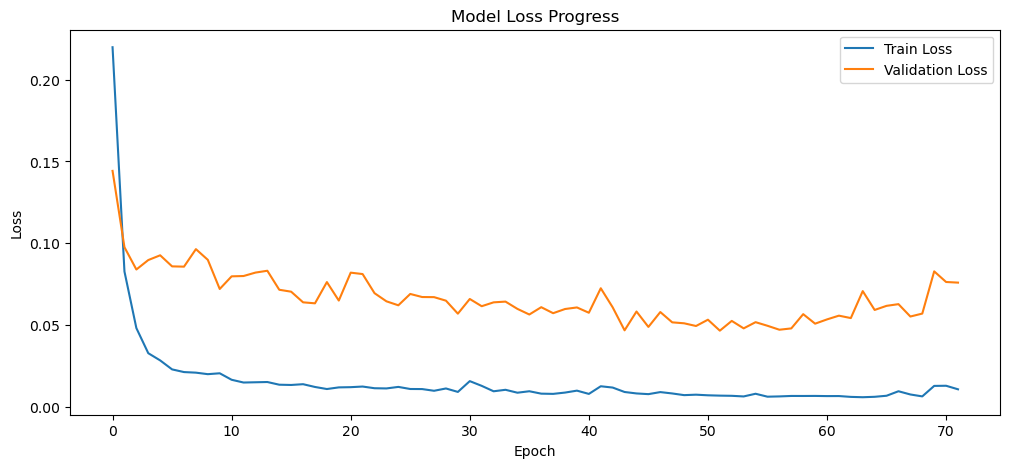

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [65]:
data_train

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,1,2022
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,1,2022
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,1,2022
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,1,2022
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,12,2023
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,12,2023
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,12,2023
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,30,12,2023


In [66]:
feature_columns = [
    'harga_petani_scaled', 
    'harga_pengecer_scaled', 
    'luas_panen_scaled', 
    'produktivitas_scaled', 
    'produksi_scaled',       # sudah dinormalisasi
    'hari_sin',
    'hari_cos',
    'bulan_sin',
    'bulan_cos',
    'tahun_norm'
]

In [67]:
fitur_pred=[
    'Tanggal',
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Hari',
    'Bulan',
    'Tahun'
]

In [68]:
fitur_predx=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Hari',
    'Bulan',
    'Tahun'
]

In [69]:
fitur_predy=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
]

In [70]:
sample_data_predict=data_train[fitur_pred].tail(60)
sample_data_predict.reset_index(drop=True, inplace=True)
sample_data_predict

,Tanggal,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,2023-11-02,5500.000000,5900.000000,9353.0426,81.165084,75914.04907,2,11,2023
1,2023-11-03,5500.000000,5900.000000,9353.0426,81.165084,75914.04907,3,11,2023
2,2023-11-04,5532.538988,5923.438498,9353.0426,81.165084,75914.04907,4,11,2023
3,2023-11-05,5529.832458,5937.652395,9353.0426,81.165084,75914.04907,5,11,2023
4,2023-11-06,5500.000000,6000.000000,9353.0426,81.165084,75914.04907,6,11,2023
5,2023-11-07,5500.000000,6000.000000,9353.0426,81.165084,75914.04907,7,11,2023
6,2023-11-08,5500.000000,6000.000000,9353.0426,81.165084,75914.04907,8,11,2023
7,2023-11-09,5500.000000,6000.000000,9353.0426,81.165084,75914.04907,9,11,2023
8,2023-11-10,5500.000000,6000.000000,9353.0426,81.165084,75914.04907,10,11,2023
9,2023-11-11,5520.618366,5956.180418,9353.0426,81.165084,75914.04907,11,11,2023


In [71]:
sample_data_predict.set_index('Tanggal', inplace=True)

In [72]:
X = sample_data_predict.values  # Semua kolom sebagai fitur
y = sample_data_predict[fitur_predy].values  # Target sama dengan fitur (karena multi-output)

In [73]:
from sklearn.model_selection import TimeSeriesSplit

In [74]:
tscv = TimeSeriesSplit(n_splits=5)

In [76]:
data_sample=data_train.copy()

In [77]:
num_scale=data_sample[kolom_scale]

In [78]:
num_data = scaler.transform(num_scale.to_numpy())
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']
scaled_num = pd.DataFrame(num_data, columns=nama_kolom_scaled_baru)
scaled_num

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.833333,0.876264,1.000000,1.000000,1.000000
1,0.833333,0.876264,1.000000,1.000000,1.000000
2,0.833333,0.876264,1.000000,1.000000,1.000000
3,0.833333,0.876264,1.000000,1.000000,1.000000
4,0.833333,0.876264,1.000000,1.000000,1.000000
...,...,...,...,...,...
723,1.333333,1.494943,-0.043225,2.394955,-0.013121
724,1.333333,1.494943,-0.043225,2.394955,-0.013121
725,1.333333,1.494943,-0.043225,2.394955,-0.013121
726,1.333333,1.494943,-0.043225,2.394955,-0.013121


In [79]:
data_sample[nama_kolom_scaled_baru]=scaled_num

In [80]:
data_sample['hari_sin'] = np.sin(2 * np.pi * data_sample['Hari']/7)
data_sample['hari_cos'] = np.cos(2 * np.pi * data_sample['Hari']/7)
data_sample['bulan_sin'] = np.sin(2 * np.pi * data_sample['Bulan']/12)
data_sample['bulan_cos'] = np.cos(2 * np.pi * data_sample['Bulan']/12)

In [81]:
tahun_min = data_sample['Tahun'].min()
tahun_max = data_sample['Tahun'].max()
data_sample['tahun_norm'] = (data_sample['Tahun'] - tahun_min) / (tahun_max - tahun_min)

In [82]:
data_sample=data_sample.set_index('Tanggal')

In [83]:
data_sample

,Komoditi,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,...,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
Tanggal,,,,,,,,,,,,,,,,,,,,,
2022-01-03,Jagung Pipil Kering,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,...,0.833333,0.876264,1.000000,1.000000,1.000000,4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-04,Jagung Pipil Kering,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,...,0.833333,0.876264,1.000000,1.000000,1.000000,-4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-05,Jagung Pipil Kering,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,...,0.833333,0.876264,1.000000,1.000000,1.000000,-9.749279e-01,-0.222521,5.000000e-01,0.866025,0.0
2022-01-06,Jagung Pipil Kering,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,...,0.833333,0.876264,1.000000,1.000000,1.000000,-7.818315e-01,0.623490,5.000000e-01,0.866025,0.0
2022-01-07,Jagung Pipil Kering,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,...,0.833333,0.876264,1.000000,1.000000,1.000000,-2.449294e-16,1.000000,5.000000e-01,0.866025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,Jagung Pipil Kering,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,-7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0
2023-12-28,Jagung Pipil Kering,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,-9.797174e-16,1.000000,-2.449294e-16,1.000000,1.0
2023-12-29,Jagung Pipil Kering,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,...,1.333333,1.494943,-0.043225,2.394955,-0.013121,7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0


In [84]:
scaled_data=data_sample[feature_columns]
scaled_data.isnull().sum()
scaled_data.columns

Index(['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled',
       'produktivitas_scaled', 'produksi_scaled', 'hari_sin', 'hari_cos',
       'bulan_sin', 'bulan_cos', 'tahun_norm'],
      dtype='object')

In [85]:
scaled_data

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
Tanggal,,,,,,,,,,
2022-01-03,0.833333,0.876264,1.000000,1.000000,1.000000,4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-04,0.833333,0.876264,1.000000,1.000000,1.000000,-4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-05,0.833333,0.876264,1.000000,1.000000,1.000000,-9.749279e-01,-0.222521,5.000000e-01,0.866025,0.0
2022-01-06,0.833333,0.876264,1.000000,1.000000,1.000000,-7.818315e-01,0.623490,5.000000e-01,0.866025,0.0
2022-01-07,0.833333,0.876264,1.000000,1.000000,1.000000,-2.449294e-16,1.000000,5.000000e-01,0.866025,0.0
...,...,...,...,...,...,...,...,...,...,...
2023-12-27,1.333333,1.494943,-0.043225,2.394955,-0.013121,-7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0
2023-12-28,1.333333,1.494943,-0.043225,2.394955,-0.013121,-9.797174e-16,1.000000,-2.449294e-16,1.000000,1.0
2023-12-29,1.333333,1.494943,-0.043225,2.394955,-0.013121,7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0


In [86]:
df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,1,2022
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,1,2022
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,1,2022
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,1,2022
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,12,2023
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,12,2023
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,12,2023
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,30,12,2023


In [87]:
data_sample.index[-1]

Timestamp('2023-12-31 00:00:00')

# Deployment Prediksi

In [112]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# 1. Siapkan data terakhir untuk prediksi
n_timesteps = 60  # Sesuaikan dengan model Anda

# Konversi scaled_data ke numpy array
if isinstance(scaled_data, pd.DataFrame):
    scaled_data_np = scaled_data.values
else:
    scaled_data_np = scaled_data

last_sequence = scaled_data_np[-n_timesteps:]
n_features = last_sequence.shape[1]  # Jumlah fitur total

# 2. Lakukan prediksi untuk N hari ke depan
days_ahead = 731
future_predictions = []

# Bentuk awal sequence untuk prediksi
current_seq = last_sequence.copy().reshape(1, n_timesteps, n_features)

for i in range(days_ahead):
    # Prediksi satu langkah ke depan
    pred_scaled = model.predict(current_seq, verbose=0)[0]  # Output: (n_output_features,)
    
    # Simpan prediksi
    future_predictions.append(pred_scaled)
    
    # Hitung tanggal prediksi untuk fitur temporal
    pred_date = data_sample.index[-1] + timedelta(days=i+1)
    
    # Hitung fitur temporal baru
    day_of_week = pred_date.weekday()
    month = pred_date.month
    year = pred_date.year
    
    # Hitung representasi siklis
    hari_sin = np.sin(2 * np.pi * day_of_week / 7)
    hari_cos = np.cos(2 * np.pi * day_of_week / 7)
    bulan_sin = np.sin(2 * np.pi * month / 12)
    bulan_cos = np.cos(2 * np.pi * month / 12)
    
    # Normalisasi tahun (gunakan min/max tahun dari data asli)
    tahun_min = data_sample.index.year.min()
    tahun_max = data_sample.index.year.max()
    tahun_norm = (year - tahun_min) / (tahun_max - tahun_min)
    
    # Gabungkan fitur prediksi dengan fitur temporal
    # Asumsikan model hanya memprediksi 5 fitur target
    full_features = np.concatenate([
        pred_scaled[:5],  # 5 fitur target
        [hari_sin, hari_cos, bulan_sin, bulan_cos, tahun_norm]  # 5 fitur temporal
    ])
    
    # Pastikan jumlah fitur sesuai
    if len(full_features) != n_features:
        # Jika tidak sesuai, sesuaikan dengan padding
        full_features = np.pad(
            full_features, 
            (0, n_features - len(full_features)), 
            'constant',
            constant_values=0
        )
    
    # Update sequence
    current_seq = np.concatenate([
        current_seq[:, 1:, :], 
        full_features.reshape(1, 1, n_features)
    ], axis=1)

# 3. Konversi hasil prediksi
future_predictions = np.array(future_predictions)

# 4. Denormalisasi hanya fitur target (5 fitur pertama)
future_predictions_denorm = scaler.inverse_transform(future_predictions[:, :5])

# 5. Buat DataFrame hasil prediksi
future_dates = [data_sample.index[-1] + timedelta(days=i+1) for i in range(days_ahead)]

df_predictions = pd.DataFrame({
    'Tanggal': future_dates,
    'harga_petani_pred': future_predictions_denorm[:, 0],
    'harga_pengecer_pred': future_predictions_denorm[:, 1],
    'luas_lahan_pred': future_predictions_denorm[:, 2],
    'produktivitas_pred': future_predictions_denorm[:, 3],
    'produksi_pred': future_predictions_denorm[:, 4]
})

# 6. Tambahkan informasi tambahan
df_predictions['hari'] = df_predictions['Tanggal'].dt.day_name()
df_predictions['bulan'] = df_predictions['Tanggal'].dt.month_name()
df_predictions['tahun'] = df_predictions['Tanggal'].dt.year

print("Hasil Prediksi:")
print(df_predictions.head())

Hasil Prediksi:
     Tanggal  harga_petani_pred  harga_pengecer_pred  luas_lahan_pred  \
0 2024-01-01        4383.593750          4538.512695     47858.546875   
1 2024-01-02        4350.718750          4526.607422     49136.988281   
2 2024-01-03        4302.641113          4498.687500     51100.757812   
3 2024-01-04        4235.274414          4459.009277     53555.488281   
4 2024-01-05        4159.549316          4415.589355     56329.433594   

   produktivitas_pred  produksi_pred       hari    bulan  tahun  
0           73.485703   385550.34375     Monday  January   2024  
1           73.297195   391489.12500    Tuesday  January   2024  
2           72.998466   402269.84375  Wednesday  January   2024  
3           72.642830   415956.21875   Thursday  January   2024  
4           72.275620   430842.12500     Friday  January   2024  


In [113]:
df_predictions

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun
0,2024-01-01,4383.593750,4538.512695,47858.546875,73.485703,385550.34375,Monday,January,2024
1,2024-01-02,4350.718750,4526.607422,49136.988281,73.297195,391489.12500,Tuesday,January,2024
2,2024-01-03,4302.641113,4498.687500,51100.757812,72.998466,402269.84375,Wednesday,January,2024
3,2024-01-04,4235.274414,4459.009277,53555.488281,72.642830,415956.21875,Thursday,January,2024
4,2024-01-05,4159.549316,4415.589355,56329.433594,72.275620,430842.12500,Friday,January,2024
...,...,...,...,...,...,...,...,...,...
726,2025-12-27,3792.831055,4257.892578,83470.789062,70.438797,562803.68750,Saturday,December,2025
727,2025-12-28,3801.580566,4260.386719,84126.046875,70.461533,567550.06250,Sunday,December,2025
728,2025-12-29,3804.372314,4262.999512,84624.234375,70.469337,570946.68750,Monday,December,2025
729,2025-12-30,3798.782227,4264.264160,84604.054688,70.456367,570618.62500,Tuesday,December,2025


In [ ]:
hasil_prediksi_2025='/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga Jagung_2025.csv'


In [115]:
df_predictions.to_csv(hasil_prediksi_2025, index=False)
print(f"DataFrame prediksi berhasil disimpan ke '{hasil_prediksi_2025}'")

DataFrame prediksi berhasil disimpan ke '/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga Jagung_2025.csv'


In [90]:
def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

In [91]:
df_aktual = df_harga[(df_harga['Tanggal'] >= '2024-01-01') & (df_harga['Tanggal'] <= '2024-12-31')].copy()

In [92]:
df_aktual

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
728,Jagung Pipil Kering,2024-01-01,<NA>,<NA>,Jagung,Q1-2024
729,Jagung Pipil Kering,2024-01-02,5700,6000,Jagung,Q1-2024
730,Jagung Pipil Kering,2024-01-03,5700,6000,Jagung,Q1-2024
731,Jagung Pipil Kering,2024-01-04,5700,6000,Jagung,Q1-2024
732,Jagung Pipil Kering,2024-01-05,5700,6000,Jagung,Q1-2024
...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Jagung,Q3-2024
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Jagung,Q3-2024
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Jagung,Q3-2024
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Jagung,Q3-2024


In [93]:
df_aktual=df_aktual.reset_index()
df_aktual=df_aktual.drop(columns=['index'])
df_aktual

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Jagung Pipil Kering,2024-01-01,<NA>,<NA>,Jagung,Q1-2024
1,Jagung Pipil Kering,2024-01-02,5700,6000,Jagung,Q1-2024
2,Jagung Pipil Kering,2024-01-03,5700,6000,Jagung,Q1-2024
3,Jagung Pipil Kering,2024-01-04,5700,6000,Jagung,Q1-2024
4,Jagung Pipil Kering,2024-01-05,5700,6000,Jagung,Q1-2024
...,...,...,...,...,...,...
361,Jagung Pipil Kering,2024-12-27,3900,4000,Jagung,Q3-2024
362,Jagung Pipil Kering,2024-12-28,3900,4000,Jagung,Q3-2024
363,Jagung Pipil Kering,2024-12-29,3900,4000,Jagung,Q3-2024
364,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Jagung,Q3-2024


In [94]:
kolom_harga=[
    'Tanggal',
    'Harga Petani', 
    'Harga Pengecer'
]

In [95]:
df_aktual = df_aktual[kolom_harga]

In [96]:
df_aktual

,Tanggal,Harga Petani,Harga Pengecer
0,2024-01-01,<NA>,<NA>
1,2024-01-02,5700,6000
2,2024-01-03,5700,6000
3,2024-01-04,5700,6000
4,2024-01-05,5700,6000
...,...,...,...
361,2024-12-27,3900,4000
362,2024-12-28,3900,4000
363,2024-12-29,3900,4000
364,2024-12-30,<NA>,<NA>


In [97]:
print("DataFrame sebelum imputasi:")
print(df_aktual)
print("\nMissing values sebelum imputasi:")
print(df_aktual['Harga Petani'].isnull().sum())
print(df_aktual['Harga Pengecer'].isnull().sum())


# Pastikan kolom 'Tanggal' adalah indeks

# Terapkan fungsi stl_imputation ke kolom 'Harga Petani'
# Karena STL bekerja per seri waktu, Anda harus menerapkan ini per komoditi jika Anda memiliki banyak komoditi.
# Jika Anda ingin menerapkan per komoditas, Anda harus mengulanginya:

# Untuk satu komoditi (seperti dalam contoh df saat ini):
df_aktual['Harga Petani'] = stl_imputation(df['Harga Petani'], period=30) # Asumsi periode bulanan
df_aktual['Harga Pengecer'] = stl_imputation(df['Harga Pengecer'], period=30)


print("\nDataFrame setelah imputasi:")
print(df_aktual)
print("\nMissing values setelah imputasi:")
print(df_aktual['Harga Petani'].isnull().sum())
print(df_aktual['Harga Pengecer'].isnull().sum())

DataFrame sebelum imputasi:
       Tanggal Harga Petani Harga Pengecer
0   2024-01-01         <NA>           <NA>
1   2024-01-02         5700           6000
2   2024-01-03         5700           6000
3   2024-01-04         5700           6000
4   2024-01-05         5700           6000
..         ...          ...            ...
361 2024-12-27         3900           4000
362 2024-12-28         3900           4000
363 2024-12-29         3900           4000
364 2024-12-30         <NA>           <NA>
365 2024-12-31         <NA>           <NA>

[366 rows x 3 columns]

Missing values sebelum imputasi:
114
114
Tidak ada missing value untuk diisi.
Tidak ada missing value untuk diisi.

DataFrame setelah imputasi:
       Tanggal  Harga Petani  Harga Pengecer
0   2024-01-01   4800.000000     5000.000000
1   2024-01-02   4800.000000     5000.000000
2   2024-01-03   4800.000000     5000.000000
3   2024-01-04   4800.000000     5000.000000
4   2024-01-05   4800.000000     5000.000000
..         ...   

In [98]:
df_aktual=df_aktual.to_pandas()
df_aktual

,Tanggal,Harga Petani,Harga Pengecer
0,2024-01-01,4800.000000,5000.000000
1,2024-01-02,4800.000000,5000.000000
2,2024-01-03,4800.000000,5000.000000
3,2024-01-04,4800.000000,5000.000000
4,2024-01-05,4800.000000,5000.000000
...,...,...,...
361,2024-12-27,3400.000000,3700.000000
362,2024-12-28,3406.324003,3663.243532
363,2024-12-29,3408.489787,3654.513687
364,2024-12-30,3400.000000,3600.000000


In [ ]:

# Menggabungkan DataFrame prediksi dan aktual
df_combined = pd.merge(df_predictions, df_aktual, on='Tanggal')




In [110]:
def calculate_rmse(y_actual, y_predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between actual and predicted values.

    Args:
        y_actual (numpy.array or list): The true/actual values.
        y_predicted (numpy.array or list): The predicted values.

    Returns:
        float: The calculated RMSE value.
    """
    y_actual = np.array(y_actual)
    y_predicted = np.array(y_predicted)

    mse = np.mean((y_actual - y_predicted)**2)
    rmse = np.sqrt(mse)
    return rmse

In [111]:
mape_harga = calculate_mape(df_combined['Harga Petani'], df_combined['harga_petani_pred'])
print(f"MAPE untuk harga: {mape_harga:.2f}%")

rmse_value = calculate_rmse(df_combined['Harga Petani'], df_combined['harga_petani_pred'])
print(f"RMSE: {rmse_value}")


MAPE untuk harga: 15.52%
RMSE: 721.5073308826875


In [101]:
df_combined

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Harga Petani,Harga Pengecer
0,2024-01-01,4383.593750,4538.512695,47858.546875,73.485703,385550.34375,Monday,January,2024,4800.000000,5000.000000
1,2024-01-02,4350.718750,4526.607422,49136.988281,73.297195,391489.12500,Tuesday,January,2024,4800.000000,5000.000000
2,2024-01-03,4302.641113,4498.687500,51100.757812,72.998466,402269.84375,Wednesday,January,2024,4800.000000,5000.000000
3,2024-01-04,4235.274414,4459.009277,53555.488281,72.642830,415956.21875,Thursday,January,2024,4800.000000,5000.000000
4,2024-01-05,4159.549316,4415.589355,56329.433594,72.275620,430842.12500,Friday,January,2024,4800.000000,5000.000000
...,...,...,...,...,...,...,...,...,...,...,...
361,2024-12-27,3694.039551,4089.188232,72733.804688,70.635445,500196.06250,Friday,December,2024,3400.000000,3700.000000
362,2024-12-28,3701.051025,4091.029541,72937.062500,70.648613,501936.65625,Saturday,December,2024,3406.324003,3663.243532
363,2024-12-29,3710.129883,4094.775146,73268.898438,70.662956,504570.90625,Sunday,December,2024,3408.489787,3654.513687
364,2024-12-30,3713.662598,4097.081055,73480.351562,70.666641,506048.31250,Monday,December,2024,3400.000000,3600.000000


In [102]:
df_combined_harga_petani=df_combined[['harga_petani_pred', 'Harga Petani']]

In [103]:
df_combined_harga_petani

,harga_petani_pred,Harga Petani
0,4383.593750,4800.000000
1,4350.718750,4800.000000
2,4302.641113,4800.000000
3,4235.274414,4800.000000
4,4159.549316,4800.000000
...,...,...
361,3694.039551,3400.000000
362,3701.051025,3406.324003
363,3710.129883,3408.489787
364,3713.662598,3400.000000


# Menyimpan Model

In [104]:
model_path='ModelJagung_temp1.keras'

In [105]:
try:
    model.save(model_path)
    print(f"Model berhasil disimpan di: {model_path}")
except Exception as e:
    print(f"Gagal menyimpan model: {e}")

Model berhasil disimpan di: ModelJagung_temp1.keras


In [106]:
hasil_prediksi='Data Prediksi Harga Jagung_temp1.csv'
data_bahan_prediksi_normalisasi='Data Jagung Normalisasi_temp1.csv'

In [107]:
df_combined.to_csv(hasil_prediksi, index=False)
print(f"DataFrame prediksi berhasil disimpan ke '{hasil_prediksi}'")


DataFrame prediksi berhasil disimpan ke 'Data Prediksi Harga Jagung_temp1.csv'


In [108]:
data_sample.to_csv(data_bahan_prediksi_normalisasi)
print(f"DataFrame normalisasi jagung berhasil disimpan ke '{data_bahan_prediksi_normalisasi}'")

DataFrame normalisasi jagung berhasil disimpan ke 'Data Jagung Normalisasi_temp1.csv'


In [109]:
from sklearn.preprocessing import MinMaxScaler
import joblib


# Simpan scaler ke file
joblib.dump(scaler, 'scaler_jagung_temp1.pkl')


['scaler_jagung_temp1.pkl']